In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

In [ ]:
cd drive/MyDrive/Datalab/practice

/content/drive/MyDrive/Datalab/practice


In [ ]:
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim


In [ ]:
df_SDG = pd.read_csv("../data/SDG.csv")

In [ ]:
df_SDG

,Country Name,Country Code,Series Name,Series Code,1990 [YR1990],1991 [YR1991],1992 [YR1992],1993 [YR1993],1994 [YR1994],1995 [YR1995],...,2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020]
0,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,..,..,..,..,..,..,...,43.2220191955566,69.0999984741211,68.2906494140625,89.5,71.5,97.6999969482422,97.6999969482422,96.6161346435547,97.6999969482422,97.6999969482422
1,Afghanistan,AFG,Annualized average growth rate in per capita r...,SI.SPR.PCAP.ZG,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
2,Afghanistan,AFG,Births attended by skilled health staff (% of ...,SH.STA.BRTC.ZS,..,..,..,..,..,..,...,38.6,39.9,..,45.2,50.5,..,53.4,58.8,..,..
3,Afghanistan,AFG,Coverage of social insurance programs (% of po...,per_si_allsi.cov_pop_tot,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
4,Afghanistan,AFG,"Debt service (PPG and IMF only, % of exports o...",DT.TDS.DPPF.XP.ZS,..,..,..,..,..,..,...,0.313643499018774,0.553390349525131,1.55478392301891,1.87526084674456,2.80585396332281,3.73588202243344,3.54864769227737,2.59522269404553,2.39042205413598,2.2440821580961
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1566,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1569,Data from database: Sustainable Development Go...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_finance = pd.read_csv("../data/Finance_Grobal.csv", encoding='utf-8', encoding_errors='ignore')

In [ ]:
df_finance

,Country Name,Country Code,Series Name,Series Code,1960 [YR1960],1961 [YR1961],1962 [YR1962],1963 [YR1963],1964 [YR1964],1965 [YR1965],...,2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021]
0,Afghanistan,AFG,Account at a formal financial institution (% a...,GFDD.AI.05,..,..,..,..,..,..,...,..,..,9.961001,..,..,14.54708,..,..,..,9.653822
1,Afghanistan,AFG,"Bank accounts per 1,000 adults",GFDD.AI.01,..,..,..,..,..,..,...,166.11281,155.78115,172.80729,181.08728,182.14525,166.16705,174.29911,183.28731,..,..
2,Afghanistan,AFG,Bank deposits to GDP (%),GFDD.OI.02,0.7479339,1.101215,1.512195,1.088757,1.7,2.139073,...,18.08667,17.72008,17.20384,17.11684,18.96479,19.07627,18.88173,16.91687,17.64849,..
3,Afghanistan,AFG,Central bank assets to GDP (%),GFDD.DI.06,13.25207,16.49797,20.4187,16.30473,19.56944,13.42163,...,3.233945,2.826811,2.551267,2.497572,1.992255,1.323696,0.6103021,0.0750632,0.1159692,..
4,Afghanistan,AFG,Credit card (% age 15+),GFDD.AI.20,..,..,..,..,..,..,...,..,..,1.385928,..,..,1.063656,..,..,..,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2475,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2476,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2477,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2478,Data from database: Global Financial Development,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_SDG.columns = df_SDG.columns.str.split('[').str[0].str.strip()
df_finance.columns = df_finance.columns.str.split('[').str[0].str.strip()
print(df_SDG.columns)

Index(['Country Name', 'Country Code', 'Series Name', 'Series Code', '1990',
       '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999',
       '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008',
       '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017',
       '2018', '2019', '2020'],
      dtype='object')


In [ ]:
df_SDG.loc[df_SDG['Country Code'].isna()]

,Country Name,Country Code,Series Name,Series Code,1990,1991,1992,1993,1994,1995,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
1566,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1569,Data from database: Sustainable Development Go...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1570,Last Updated: 07/22/2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
SDG_clean = df_SDG.dropna(subset=['Country Code'])
finance_clean = df_finance.dropna(subset=['Country Code'])

In [ ]:
SDG_clean

,Country Name,Country Code,Series Name,Series Code,1990,1991,1992,1993,1994,1995,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,..,..,..,..,..,..,...,43.2220191955566,69.0999984741211,68.2906494140625,89.5,71.5,97.6999969482422,97.6999969482422,96.6161346435547,97.6999969482422,97.6999969482422
1,Afghanistan,AFG,Annualized average growth rate in per capita r...,SI.SPR.PCAP.ZG,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
2,Afghanistan,AFG,Births attended by skilled health staff (% of ...,SH.STA.BRTC.ZS,..,..,..,..,..,..,...,38.6,39.9,..,45.2,50.5,..,53.4,58.8,..,..
3,Afghanistan,AFG,Coverage of social insurance programs (% of po...,per_si_allsi.cov_pop_tot,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
4,Afghanistan,AFG,"Debt service (PPG and IMF only, % of exports o...",DT.TDS.DPPF.XP.ZS,..,..,..,..,..,..,...,0.313643499018774,0.553390349525131,1.55478392301891,1.87526084674456,2.80585396332281,3.73588202243344,3.54864769227737,2.59522269404553,2.39042205413598,2.2440821580961
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1561,Zimbabwe,ZWE,Annualized average growth rate in per capita r...,SI.SPR.PCAP.ZG,..,..,..,..,..,..,...,..,..,..,..,..,..,-3.5,..,..,..
1562,Zimbabwe,ZWE,Births attended by skilled health staff (% of ...,SH.STA.BRTC.ZS,..,..,..,..,69.2,..,...,66.2,..,..,80,78.1,..,..,..,86,..
1563,Zimbabwe,ZWE,Coverage of social insurance programs (% of po...,per_si_allsi.cov_pop_tot,..,..,..,..,..,..,...,2.65503997288927,..,..,..,..,..,3.407481109,..,4.80744769,..
1564,Zimbabwe,ZWE,"Debt service (PPG and IMF only, % of exports o...",DT.TDS.DPPF.XP.ZS,19.539947884211,18.480157264191,25.8537260197139,24.4693678057418,18.7404217093514,..,...,0.463397333390967,0.657740549404177,2.95963512936197,3.38738788212339,3.93246699955856,5.88555514245422,2.98943667154859,1.7407163281666,1.30768536023995,0.748035122748019


In [ ]:
# SDG_clean = SDG_clean.drop(['Country Code', 'Series Name'], axis=1)
# finance_clean = finance_clean.drop(['Country Code', 'Series Name'], axis=1)

In [ ]:
print(len(SDG_clean['Country Name'].unique()))
print(len(finance_clean['Country Name'].unique()))
print(len(SDG_clean['Series Code'].unique()))
print(len(finance_clean['Series Code'].unique()))

261
225
6
11


In [ ]:
SDG_clean.head(4)

,Country Name,Country Code,Series Name,Series Code,1990,1991,1992,1993,1994,1995,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,..,..,..,..,..,..,...,43.2220191955566,69.0999984741211,68.2906494140625,89.5,71.5,97.6999969482422,97.6999969482422,96.6161346435547,97.6999969482422,97.6999969482422
1,Afghanistan,AFG,Annualized average growth rate in per capita r...,SI.SPR.PCAP.ZG,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
2,Afghanistan,AFG,Births attended by skilled health staff (% of ...,SH.STA.BRTC.ZS,..,..,..,..,..,..,...,38.6,39.9,..,45.2,50.5,..,53.4,58.8,..,..
3,Afghanistan,AFG,Coverage of social insurance programs (% of po...,per_si_allsi.cov_pop_tot,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..


In [ ]:
finance_clean.head(4)

,Country Name,Country Code,Series Name,Series Code,1960,1961,1962,1963,1964,1965,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Afghanistan,AFG,Account at a formal financial institution (% a...,GFDD.AI.05,..,..,..,..,..,..,...,..,..,9.961001,..,..,14.54708,..,..,..,9.653822
1,Afghanistan,AFG,"Bank accounts per 1,000 adults",GFDD.AI.01,..,..,..,..,..,..,...,166.11281,155.78115,172.80729,181.08728,182.14525,166.16705,174.29911,183.28731,..,..
2,Afghanistan,AFG,Bank deposits to GDP (%),GFDD.OI.02,0.7479339,1.101215,1.512195,1.088757,1.7,2.139073,...,18.08667,17.72008,17.20384,17.11684,18.96479,19.07627,18.88173,16.91687,17.64849,..
3,Afghanistan,AFG,Central bank assets to GDP (%),GFDD.DI.06,13.25207,16.49797,20.4187,16.30473,19.56944,13.42163,...,3.233945,2.826811,2.551267,2.497572,1.992255,1.323696,0.6103021,0.0750632,0.1159692,..


In [ ]:
SDG_clean = SDG_clean.replace('..', np.nan)
finance_clean = finance_clean.replace('..', np.nan)

In [ ]:
SDG_clean.head(4)

,Country Name,Country Code,Series Name,Series Code,1990,1991,1992,1993,1994,1995,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,43.2220191955566,69.0999984741211,68.2906494140625,89.5,71.5,97.6999969482422,97.6999969482422,96.6161346435547,97.6999969482422,97.6999969482422
1,Afghanistan,AFG,Annualized average growth rate in per capita r...,SI.SPR.PCAP.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Births attended by skilled health staff (% of ...,SH.STA.BRTC.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,38.6,39.9,NaN,45.2,50.5,NaN,53.4,58.8,NaN,NaN
3,Afghanistan,AFG,Coverage of social insurance programs (% of po...,per_si_allsi.cov_pop_tot,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
SDG_null = SDG_clean.groupby('Series Code').apply(lambda x: x.isnull().mean() * 100)
finance_null = finance_clean.groupby('Series Code').apply(lambda x: x.isnull().mean() * 100)


/tmp/ipython-input-198292028.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  SDG_null = SDG_clean.groupby('Series Code').apply(lambda x: x.isnull().mean() * 100)
/tmp/ipython-input-198292028.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  finance_null = finance_clean.groupby('Series Code').apply(lambda x: x.isnull().mean() * 100)


In [ ]:
SDG_null

,Country Name,Country Code,Series Name,Series Code,1990,1991,1992,1993,1994,1995,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
Series Code,,,,,,,,,,,,,,,,,,,,,
DT.TDS.DPPF.XP.ZS,0.0,0.0,0.0,0.0,57.471264,57.088123,56.704981,55.172414,51.724138,52.490421,...,44.061303,44.827586,44.827586,44.444444,44.061303,44.061303,45.210728,45.977011,47.126437,50.574713
EG.ELC.ACCS.ZS,0.0,0.0,0.0,0.0,58.620690,54.789272,48.275862,42.911877,40.613027,37.547893,...,0.766284,0.383142,0.383142,0.383142,0.383142,0.383142,0.383142,0.766284,0.383142,0.766284
SH.STA.BRTC.ZS,0.0,0.0,0.0,0.0,72.413793,81.226054,79.310345,77.777778,78.160920,69.348659,...,60.153257,59.003831,60.536398,55.938697,63.218391,64.367816,68.199234,59.386973,97.701149,99.616858
SI.SPR.PCAP.ZG,0.0,0.0,0.0,0.0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,98.850575,98.467433,99.616858,97.318008,95.402299,96.934866,95.785441,92.337165,85.440613,95.019157
SL.IND.EMPL.ZS,0.0,0.0,0.0,0.0,100.000000,11.494253,11.494253,11.494253,11.494253,11.494253,...,11.494253,11.494253,11.494253,11.494253,11.494253,11.494253,11.494253,11.494253,11.494253,100.000000
per_si_allsi.cov_pop_tot,0.0,0.0,0.0,0.0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,86.973180,85.057471,90.804598,88.505747,86.973180,88.122605,90.038314,89.655172,93.869732,100.000000


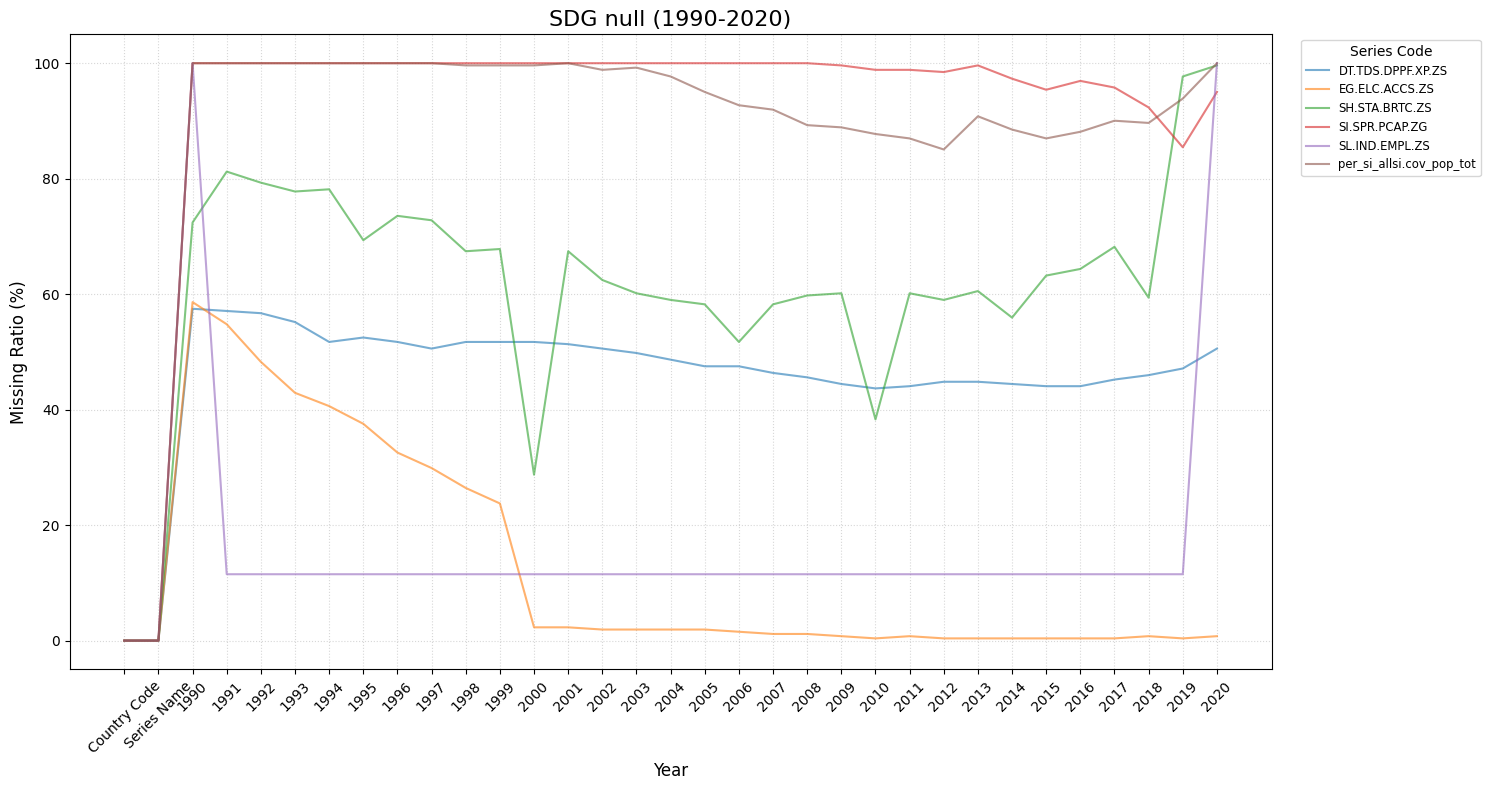

In [ ]:
year_cols = [col for col in SDG_clean.columns if col not in ['Country Name', 'Series Code']]

plt.close('all')
plt.figure(figsize=(15, 8))

for series_code in SDG_null.index:
    y_values = SDG_null.loc[series_code, year_cols]

    plt.plot(year_cols, y_values,
             label=series_code,
             alpha=0.6,
             linewidth=1.5)

plt.title('SDG null (1990-2020)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Missing Ratio (%)', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(-5, 105)
plt.grid(True, linestyle=':', alpha=0.5)

plt.legend(title='Series Code', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()

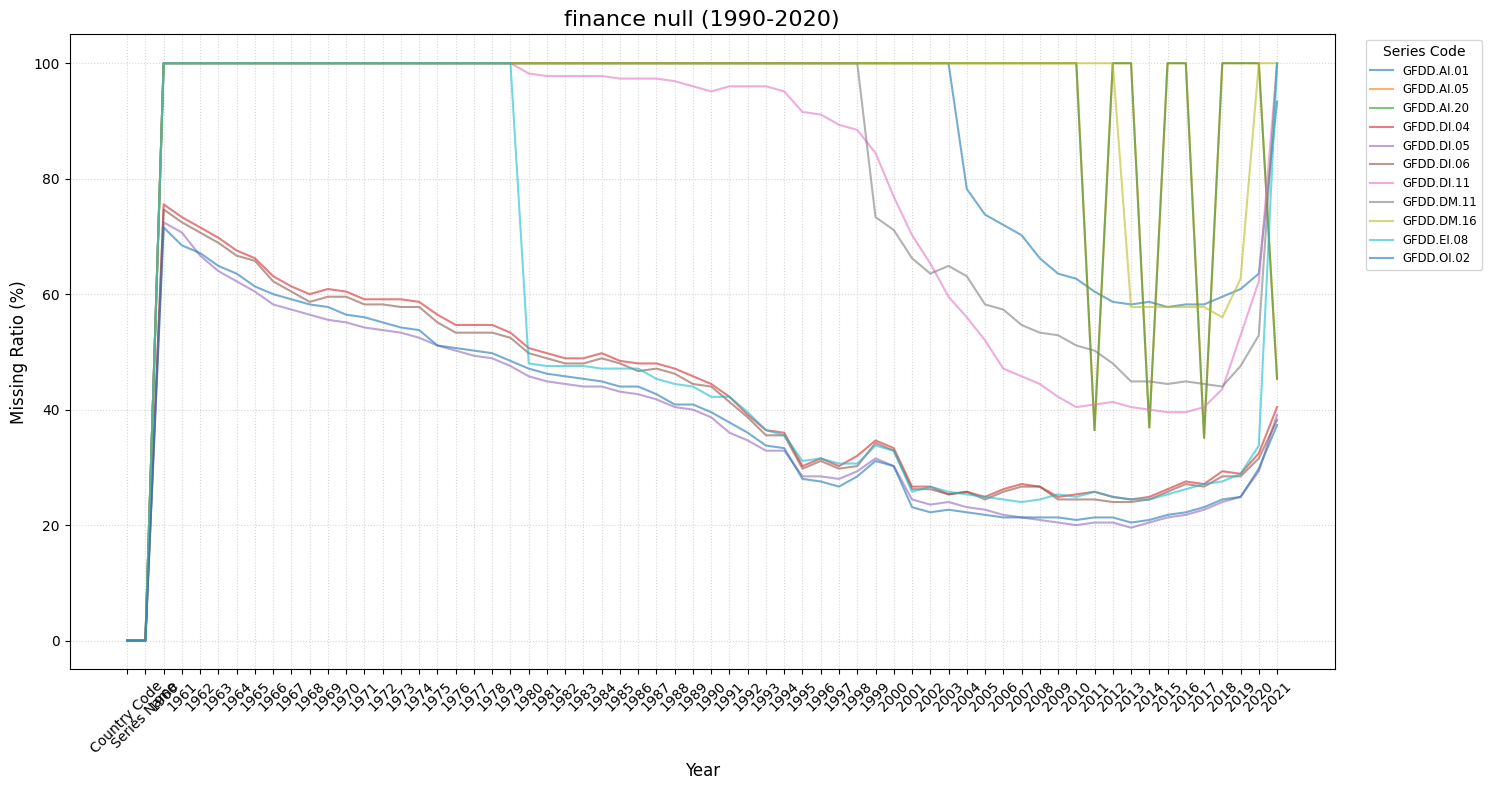

In [ ]:
plt.close('all')
plt.figure(figsize=(15, 8))

year_cols = [col for col in finance_clean.columns if col not in ['Country Name', 'Series Code']]

for series_code in finance_null.index:
    y_values = finance_null.loc[series_code, year_cols]

    plt.plot(year_cols, y_values,
             label=series_code,
             alpha=0.6,
             linewidth=1.5)

plt.title('finance null (1990-2020)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Missing Ratio (%)', fontsize=12)
plt.xticks(rotation=45) # 연도가 겹치지 않게 회전
plt.ylim(-5, 105)       # 비율이므로 0~100 범위 고정
plt.grid(True, linestyle=':', alpha=0.5)

# 5. 범례 (시리즈가 많으면 그래프 옆으로 배치)
plt.legend(title='Series Code', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()

In [ ]:
target_series = ['SI.SPR.PCAP.ZG', 'per_si_allsi.cov_pop_tot', 'GFDD.DM.16', 'GFDD.AI.20']

SDG_final = SDG_clean[~SDG_clean['Series Code'].isin(target_series)]
finance_final = finance_clean[~finance_clean['Series Code'].isin(target_series)]

print(f"{SDG_final['Series Code'].nunique()}")
print(f"{finance_final['Series Code'].nunique()}")


4
9


In [ ]:
print(len(SDG_final.columns))

35


In [ ]:
print(len(finance_final.columns))

66


In [ ]:
SDG_final

,Country Name,Country Code,Series Name,Series Code,1990,1991,1992,1993,1994,1995,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,43.2220191955566,69.0999984741211,68.2906494140625,89.5,71.5,97.6999969482422,97.6999969482422,96.6161346435547,97.6999969482422,97.6999969482422
2,Afghanistan,AFG,Births attended by skilled health staff (% of ...,SH.STA.BRTC.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,38.6,39.9,NaN,45.2,50.5,NaN,53.4,58.8,NaN,NaN
4,Afghanistan,AFG,"Debt service (PPG and IMF only, % of exports o...",DT.TDS.DPPF.XP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,0.313643499018774,0.553390349525131,1.55478392301891,1.87526084674456,2.80585396332281,3.73588202243344,3.54864769227737,2.59522269404553,2.39042205413598,2.2440821580961
5,Afghanistan,AFG,Employment in industry (% of total employment)...,SL.IND.EMPL.ZS,NaN,12.4300003051758,12.210000038147,11.5699996948242,11.4799995422363,11.5100002288818,...,14.75,15.7700004577637,16.3299999237061,16.7700004577637,17.1700000762939,17.3199996948242,18.0300006866455,18.4599990844727,18.5499992370605,NaN
6,Albania,ALB,Access to electricity (% of population),EG.ELC.ACCS.ZS,100,100,100,100,100,100,...,100,99.9000015258789,100,99.9499969482422,99.9800033569336,99.8899993896484,99.8899993896484,100,100,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1559,Zambia,ZMB,Employment in industry (% of total employment)...,SL.IND.EMPL.ZS,NaN,7.8600001335144,7.76999998092651,7.6100001335144,7.28000020980835,7.19999980926514,...,9.35999965667725,10.1000003814697,10.3299999237061,10.4899997711182,10.6000003814697,10.6800003051758,10.6899995803833,10.6099996566772,10.5299997329712,NaN
1560,Zimbabwe,ZWE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,28.2,31.163667678833,28.1,31.948579788208,...,36.9000015258789,44,40.4983749389648,32.2999992370605,33.7000007629395,42.5617294311523,44.1786346435547,45.5726470947266,46.7814750671387,52.7476692199707
1562,Zimbabwe,ZWE,Births attended by skilled health staff (% of ...,SH.STA.BRTC.ZS,NaN,NaN,NaN,NaN,69.2,NaN,...,66.2,NaN,NaN,80,78.1,NaN,NaN,NaN,86,NaN
1564,Zimbabwe,ZWE,"Debt service (PPG and IMF only, % of exports o...",DT.TDS.DPPF.XP.ZS,19.539947884211,18.480157264191,25.8537260197139,24.4693678057418,18.7404217093514,NaN,...,0.463397333390967,0.657740549404177,2.95963512936197,3.38738788212339,3.93246699955856,5.88555514245422,2.98943667154859,1.7407163281666,1.30768536023995,0.748035122748019


In [ ]:
finance_final

,Country Name,Country Code,Series Name,Series Code,1960,1961,1962,1963,1964,1965,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Afghanistan,AFG,Account at a formal financial institution (% a...,GFDD.AI.05,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,9.961001,NaN,NaN,14.54708,NaN,NaN,NaN,9.653822
1,Afghanistan,AFG,"Bank accounts per 1,000 adults",GFDD.AI.01,NaN,NaN,NaN,NaN,NaN,NaN,...,166.11281,155.78115,172.80729,181.08728,182.14525,166.16705,174.29911,183.28731,NaN,NaN
2,Afghanistan,AFG,Bank deposits to GDP (%),GFDD.OI.02,0.7479339,1.101215,1.512195,1.088757,1.7,2.139073,...,18.08667,17.72008,17.20384,17.11684,18.96479,19.07627,18.88173,16.91687,17.64849,NaN
3,Afghanistan,AFG,Central bank assets to GDP (%),GFDD.DI.06,13.25207,16.49797,20.4187,16.30473,19.56944,13.42163,...,3.233945,2.826811,2.551267,2.497572,1.992255,1.323696,0.6103021,0.0750632,0.1159692,NaN
5,Afghanistan,AFG,Credit to government and state-owned enterpris...,GFDD.EI.08,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2469,Zimbabwe,ZWE,Credit to government and state-owned enterpris...,GFDD.EI.08,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2471,Zimbabwe,ZWE,Deposit money bank assets to deposit money ban...,GFDD.DI.04,NaN,NaN,NaN,NaN,NaN,NaN,...,74.83862,76.27381,79.32772,76.16954,66.65643,58.82729,49.10462,53.29511,72.93955,76.89014
2472,Zimbabwe,ZWE,Insurance company assets to GDP (%),GFDD.DI.11,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2473,Zimbabwe,ZWE,Gross portfolio debt assets to GDP (%),GFDD.DM.11,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
import pandas as pd

common_years = [str(year) for year in range(1990, 2021)]
base_cols = ['Country Name', 'Country Code','Series Code']
target_cols = base_cols + common_years

common_countries = set(SDG_final['Country Name']) & set(finance_final['Country Name'])
print(len(common_countries))

sdg_filtered = SDG_final[SDG_final['Country Name'].isin(common_countries)][target_cols].copy()
finance_filtered = finance_final[finance_final['Country Name'].isin(common_countries)][target_cols].copy()

df_combined = pd.concat([sdg_filtered, finance_filtered], axis=0, ignore_index=True)

df_combined = df_combined.sort_values(by=['Country Name', 'Series Code']).reset_index(drop=True)

print(f"shape: {df_combined.shape}") # (행, 열)
print(f"year: {df_combined.columns[2]} ~ {df_combined.columns[-1]}")
df_combined.head()

214
shape: (2782, 34)
year: Series Code ~ 2020


,Country Name,Country Code,Series Code,1990,1991,1992,1993,1994,1995,1996,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Afghanistan,AFG,DT.TDS.DPPF.XP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.313643499018774,0.553390349525131,1.55478392301891,1.87526084674456,2.80585396332281,3.73588202243344,3.54864769227737,2.59522269404553,2.39042205413598,2.2440821580961
1,Afghanistan,AFG,EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,43.2220191955566,69.0999984741211,68.2906494140625,89.5,71.5,97.6999969482422,97.6999969482422,96.6161346435547,97.6999969482422,97.6999969482422
2,Afghanistan,AFG,GFDD.AI.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,139.43751,166.11281,155.78115,172.80729,181.08728,182.14525,166.16705,174.29911,183.28731,NaN
3,Afghanistan,AFG,GFDD.AI.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.005012,NaN,NaN,9.961001,NaN,NaN,14.54708,NaN,NaN,NaN
4,Afghanistan,AFG,GFDD.DI.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,77.96436,56.26987,59.72195,59.32874,60.26381,65.52003,73.74906,84.97005,97.7129,96.25589


In [ ]:
import pandas as pd
import numpy as np

# 1. 세계은행 국가 메타데이터 가져오기 (WDI 라이브러리 대용)
# 국가 코드(ISO3), 지역(Region), 소득수준(IncomeGroup) 정보를 포함합니다.
url = "https://databank.worldbank.org/data/download/site-content/CLASS.xlsx"
try:
    # 엑셀 파일에서 국가 정보 시트 읽기
    meta_df = pd.read_excel(url, sheet_name='List of economies')
    # 필요한 컬럼만 선택 (Code는 ISO3 국가코드와 매칭)
    meta_df = meta_df[['Code', 'Region', 'Income group']]
    meta_df.columns = ['Country Code', 'Region', 'Income Group']
except:
    print("서버 연결 실패 시, 수동 매핑 혹은 다른 경로를 사용해야 합니다.")

# 2. 기존 df_combined에 메타데이터 합치기
# df_combined에 'Country Code' 컬럼이 있다고 가정합니다.
df_with_meta = pd.merge(df_combined, meta_df, on='Country Code', how='left')

# 3. 매핑되지 않은 국가 확인 (지역 정보가 없는 행)
missing_meta = df_with_meta[df_with_meta['Region'].isnull()]['Country Name'].unique()
print(f"메타데이터 매핑 실패 국가 수: {len(missing_meta)}")

메타데이터 매핑 실패 국가 수: 3


In [ ]:
# Region이 NaN인 행들의 'Country Name' 유니크 값 추출
missing_countries = df_with_meta[df_with_meta['Region'].isnull()]['Country Name'].unique()

print(f"매핑 실패 국가 ({len(missing_countries)}개):")
print(missing_countries)

매핑 실패 국가 (3개):
['IBRD only' 'IDA total' 'Least developed countries: UN classification']


In [ ]:
df_with_meta.head(4)

,Country Name,Country Code,Series Code,1990,1991,1992,1993,1994,1995,1996,...,2013,2014,2015,2016,2017,2018,2019,2020,Region,Income Group
0,Afghanistan,AFG,DT.TDS.DPPF.XP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.55478392301891,1.87526084674456,2.80585396332281,3.73588202243344,3.54864769227737,2.59522269404553,2.39042205413598,2.2440821580961,South Asia,Low income
1,Afghanistan,AFG,EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,68.2906494140625,89.5,71.5,97.6999969482422,97.6999969482422,96.6161346435547,97.6999969482422,97.6999969482422,South Asia,Low income
2,Afghanistan,AFG,GFDD.AI.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,155.78115,172.80729,181.08728,182.14525,166.16705,174.29911,183.28731,NaN,South Asia,Low income
3,Afghanistan,AFG,GFDD.AI.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,9.961001,NaN,NaN,14.54708,NaN,NaN,NaN,South Asia,Low income


In [ ]:
# 1. 분석 구간 설정 (데이터가 가장 안정적인 구간)
stable_years = [str(y) for y in range(2000, 2016)]

# 2. '전체 기간'이 아닌 '안정기' 동안의 결측치 비율 계산
series_null_stable = df_with_meta.groupby('Series Code')[stable_years].apply(lambda x: x.isnull().mean().mean() * 100)

# 3. 안정기에도 결측치가 80%가 넘는 '진짜 부실 지표'만 삭제 대상으로 선정
bad_series = series_null_stable[series_null_stable > 80].index

# 4. 필터링 실행 (억울하게 잘리는 지표 방지)
df_filtered = df_with_meta[~df_with_meta['Series Code'].isin(bad_series)].copy()

print(f"삭제된 지표 수: {len(bad_series)}")
print(f"살아남은 지표 수: {df_filtered['Series Code'].nunique()}")

삭제된 지표 수: 1
살아남은 지표 수: 12


In [ ]:
bad_series

Index(['GFDD.AI.05'], dtype='object', name='Series Code')

In [ ]:
bad_series

Index(['GFDD.AI.05'], dtype='object', name='Series Code')

In [ ]:
# 1. 실제 데이터프레임에 존재하는 연도 컬럼들만 리스트로 만듭니다.
# (1960년부터 2021년까지 중 실제 존재하는 것만 필터링)
existing_year_cols = [col for col in df_filtered.columns if col.isdigit()]

# 2. 만약 특정 범위(예: 1990~2020)만 보고 싶다면 이렇게 필터링합니다.
# existing_year_cols = [col for col in existing_year_cols if 1990 <= int(col) <= 2020]

print(f"분석에 사용될 연도 컬럼 개수: {len(existing_year_cols)}개")

# 3. 소득 수준별 결측치 비율 계산 (에러 방지용)
if len(existing_year_cols) > 0:
    income_null_stats = df_filtered.groupby('Income Group')[existing_year_cols].apply(
        lambda x: x.isnull().mean().mean() * 100
    )

    null_report = income_null_stats.reset_index()
    null_report.columns = ['Income Group', 'Missing Value Percentage (%)']
    null_report = null_report.sort_values(by='Missing Value Percentage (%)', ascending=False)

    print("\n### 소득 수준별 결측치 비율 보고서 ###")
    print(null_report.to_string(index=False))
else:
    print("오류: 데이터프레임에 연도(숫자 형식) 컬럼이 존재하지 않습니다. 컬럼명을 확인해주세요.")

분석에 사용될 연도 컬럼 개수: 31개

### 소득 수준별 결측치 비율 보고서 ###
       Income Group  Missing Value Percentage (%)
        High income                     47.123307
         Low income                     38.271605
Upper middle income                     33.607223
Lower middle income                     31.218300


In [ ]:
# SDG_clean = SDG_clean.drop(['Country Code', 'Series Name'], axis=1)
# finance_clean = finance_clean.drop(['Country Code', 'Series Name'], axis=1)

In [ ]:
df_filtered

,Country Name,Country Code,Series Code,1990,1991,1992,1993,1994,1995,1996,...,2013,2014,2015,2016,2017,2018,2019,2020,Region,Income Group
0,Afghanistan,AFG,DT.TDS.DPPF.XP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.55478392301891,1.87526084674456,2.80585396332281,3.73588202243344,3.54864769227737,2.59522269404553,2.39042205413598,2.2440821580961,South Asia,Low income
1,Afghanistan,AFG,EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,68.2906494140625,89.5,71.5,97.6999969482422,97.6999969482422,96.6161346435547,97.6999969482422,97.6999969482422,South Asia,Low income
2,Afghanistan,AFG,GFDD.AI.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,155.78115,172.80729,181.08728,182.14525,166.16705,174.29911,183.28731,NaN,South Asia,Low income
4,Afghanistan,AFG,GFDD.DI.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,59.72195,59.32874,60.26381,65.52003,73.74906,84.97005,97.7129,96.25589,South Asia,Low income
5,Afghanistan,AFG,GFDD.DI.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,33.32521,34.01956,33.82253,37.22271,36.86128,36.60749,34.9591,37.20945,South Asia,Low income
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2777,Zimbabwe,ZWE,GFDD.DM.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sub-Saharan Africa,Lower middle income
2778,Zimbabwe,ZWE,GFDD.EI.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sub-Saharan Africa,Lower middle income
2779,Zimbabwe,ZWE,GFDD.OI.02,0.0409779,0.0434212,0.0611254,0.1059968,0.1450484,0.176563,0.1920164,...,19.93279,21.83512,23.46486,26.78586,33.47981,40.10917,20.65183,17.86878,Sub-Saharan Africa,Lower middle income
2780,Zimbabwe,ZWE,SH.STA.BRTC.ZS,NaN,NaN,NaN,NaN,69.2,NaN,NaN,...,NaN,80,78.1,NaN,NaN,NaN,86,NaN,Sub-Saharan Africa,Lower middle income


In [ ]:
df_filtered.to_csv('../data/merged_sdg_finance_data.csv', index=False, encoding='utf-8-sig')